In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.DB_reader import Database


from Strategies.SpotTraining.backtest_class import BacktestLL
from Strategies.SpotTraining.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [277]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [278]:
import warnings
warnings.filterwarnings('ignore')

In [279]:
#5	17	0.1	1.00	-0.75	

In [280]:
#0.08	-0.08	0.08	-0.10	1.5	60	0.3	0.6	0.50	2.0	-2.0

In [281]:
#0.04	-0.04	0.06	-0.06	1.2	60	0.3	0.6	0.8 2.0	-1.5 -> around 40, stable perf
#0.04	-0.04	0.06	-0.06	0.7	60	0.3	0.6	0.8	 2.0	-1 -> around 51, weak perf on prod sample
#0.075	-0.050	0.150	-0.100	0.45	60	0.3	0.6	0.8	 2.0	-1 -> around 41, good stable performance overall
#other combinations do not work well on prod sample

In [282]:
long_threshold = 4
short_threshold = 4

burnout_period=60
stop_profit = 0.3
makeagg_ratio = 0.6
trail_stop=0.3

take_profit=2
stop_loss=-1
aggloss_thres=0.04

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [283]:
%store -r dates_fltr

# OOT part -Jul24, Jul25

## Data preparation

In [284]:
df=pd.read_csv('df_modelling_dem1.csv')
del df['Unnamed: 0']

In [285]:
df

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,date,vwap_11_to_12,auction_price,weekday,diff_vwap_auction
0,2024-07-02 11:00:02.053000000,NaN,NaN,76.25,76.38,76.315,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
1,2024-07-02 11:00:03.270000000,NaN,NaN,76.25,76.39,76.320,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
2,2024-07-02 11:00:04.118000000,NaN,NaN,76.25,76.40,76.325,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
3,2024-07-02 11:00:09.369000000,NaN,NaN,76.25,76.39,76.320,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
4,2024-07-02 11:00:14.150000000,NaN,NaN,76.25,76.40,76.325,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
...,...,...,...,...,...,...,...,...,...,...,...,...
949009,2025-06-27 13:59:45.276000000,NaN,NaN,77.40,77.38,77.390,NaN,2025-06-27,77.759591,81.187083,5.0,-3.427492
949010,2025-06-27 13:59:45.439000000,NaN,NaN,77.40,77.39,77.395,NaN,2025-06-27,77.759591,81.187083,5.0,-3.427492
949011,2025-06-27 13:59:47.423000000,NaN,NaN,77.40,77.38,77.390,NaN,2025-06-27,77.759591,81.187083,5.0,-3.427492
949012,2025-06-27 13:59:55.043990840,77.35,1.0,NaN,77.38,77.380,-1.0,2025-06-27,77.759591,81.187083,5.0,-3.427492


In [286]:
import decimal
df = df.applymap(lambda x: float(x) if isinstance(x, decimal.Decimal) else x)

In [287]:
df['trd_price']=df['trd_price'].apply(float)
df['bid_price']=df['bid_price'].fillna(method='ffill')
df['ask_price']=df['ask_price'].fillna(method='ffill')
df['mid_price']=df['mid_price'].fillna(method='ffill')

In [288]:
df.head()

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,date,vwap_11_to_12,auction_price,weekday,diff_vwap_auction
0,2024-07-02 11:00:02.053000000,NaN,NaN,76.25,76.38,76.315,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
1,2024-07-02 11:00:03.270000000,NaN,NaN,76.25,76.39,76.320,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
2,2024-07-02 11:00:04.118000000,NaN,NaN,76.25,76.40,76.325,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
3,2024-07-02 11:00:09.369000000,NaN,NaN,76.25,76.39,76.320,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747
4,2024-07-02 11:00:14.150000000,NaN,NaN,76.25,76.40,76.325,NaN,2024-07-02,88.630414,85.676667,2.0,2.953747


## Parameters and calculations

In [289]:
data_lead=df.copy()

In [290]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(14)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['long_threshold'] = long_threshold
param_dict['short_threshold'] = short_threshold


param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [291]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])
data_lead['datetime'] = pd.to_datetime(data_lead['datetime'], errors='coerce')

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead[data_lead['trd_price'].isnull()==False])

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lead price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})


# Add hover tools to the plot
p.add_tools(hover_position, hover_lead)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

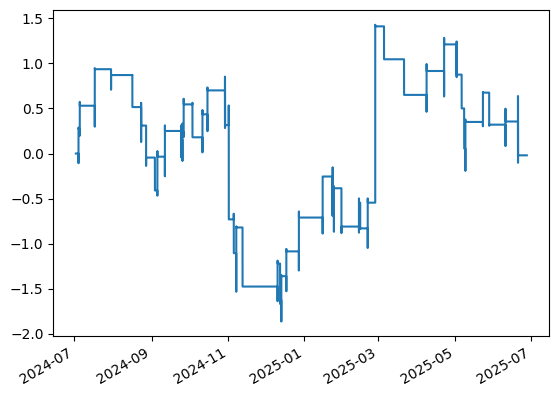

In [292]:
xx.plot()

In [293]:
#df[0:50]

In [294]:
xx[-1:]

2025-06-27 13:59:55.259371032   -0.02
dtype: float64